# Case Closed — Node-Level Suspect Prediction (GNN project) — v5

## 1. Problem framing  *(Odabir problema — Section 1)*

**Prediction level: node-level.** Each case is one small heterogeneous graph
(persons / locations / objects / clues). We classify **person nodes tagged
`suspect`** — not every person node, and not the whole graph — as *murderer*
vs *not murderer*.

**Head / loss.** Because exactly one suspect is guilty per case, this is
framed as a **per-graph softmax over the candidate suspects** (pick the most
likely suspect out of that case's suspect set), trained with **per-graph
cross-entropy**.

**Why softmax, and not ReLU / ELU / some other activation function?**
These aren't competing choices — they answer different questions and
normally both show up in the same model:

- **ReLU / ELU / GELU** are *hidden-layer* activations. They sit between
  the linear layers inside the GNN (and inside an MLP baseline) and exist
  purely to make the network non-linear — without them, stacking layers
  would collapse into one big linear function no matter how many layers you
  add. They act **elementwise** and have no notion of "these numbers belong
  to the same group and should be compared to each other."
- **Softmax** is an *output-layer* normalization, used when the answer is
  "pick one out of a set of N options." It takes N raw scores (logits) —
  one per suspect in a case — and turns them into a probability
  distribution: every value in `[0, 1]`, and the whole set **sums to 1**.
  That's what makes it usable with **cross-entropy**, which is defined in
  terms of a probability assigned to the correct class.

  Concretely: a case with 4 suspects produces 4 logits from the model.
  ReLU on those 4 numbers just clips the negative ones to 0 — the result
  doesn't sum to 1 and doesn't shrink as more suspects are added, so it
  can't be read as "how likely is each person." Softmax normalizes across
  exactly those 4 numbers, so adding a 5th suspect correctly makes each
  individual probability smaller (there's more competition for the same
  1.0 of "guilt"). That's the property node-level "pick the murderer among
  these candidates" needs, and it's *not* something ReLU/ELU are trying to
  provide.

  So the actual model still uses ReLU/ELU internally (in the GNN's hidden
  layers and the MLP baseline) — softmax is only the last step, applied to
  the per-suspect output scores within each case.

**Domain.** Whodunit reasoning over structured case data extracted from
*Case Closed* (Detective Conan) episodes: who-knows-who, who-was-where,
who-did-what, tied to physical evidence and testimony.

**Dataset.** `cases_v3` schema (loader: `case_closed_dataset.py`). Each case
is its own self-contained graph, so cases — not individual nodes — are the
natural unit for train/val/test splitting (Section 4 of the plan).

**What's new in v5 vs v4:**
- More explanation, less "trust me": what "suspects per case" means, why
  softmax specifically, and what average degree / `2E/N` actually measure
  (see the markdown cells above each relevant table/chart below).
- Suspects-per-case and average-degree are now two separate, dedicated
  chart cells (each redrawn for readability: count labels, a marked mean)
  instead of one combined figure.
- The graph layout bug from v4 (components packed non-uniformly, so the
  main graph could render as a squished, overlapping sliver) is fixed in
  `visualize_case.py`: equal-aspect rendering plus a deterministic
  component ordering.
- The leak-scoring logic is a flat, single-threshold rule now: `action`
  keys at concentration ≥ 0.65 are EXCLUDE, everything else is kept — no
  intermediate "review" tier.
- A new **edge-removal step**: every edge whose type cleared that 0.65 bar
  is stripped from **every** case — not just the suspect-touching instances
  of it, the edge *type* is removed corpus-wide. The cleaned corpus is
  written out as a new dataset, `cases_v4`, in this notebook's own folder
  (`Reo analysis/v5/cases_v4/`) — a dataset-schema version bump, distinct
  from this notebook being "v5".
- The "top leak by concentration" chart (kept, as requested) now also
  reports how many edges were actually removed for each type.
- `ep011` (Moonlight Sonata) is re-visualized *after* cleaning, next to the
  original, so the effect of the removal is visible on a real case instead
  of only as aggregate counts.
- A new closing section starts the Section 7b bucket taxonomy: every edge
  key in the cleaned corpus, categorized (`action` vs `relationship`) and
  counted, as the catalog to actually assign buckets from next.

*Domain write-up wording for the report is still open — this notebook is the analysis that feeds it.*

---

## 2. Dataset understanding & audit  *(Dataset — Section 2)*

Below: load → schema map → per-case stats → corpus rundown →
suspects-per-case → role distribution → edge catalogue → example-case
visualization → leak audit → **edge removal & cleaned-dataset export**.
This feeds the Section 6 kritički osvrt / the exclusion list in the wider
plan.


In [1]:
# --- load data --------------------------------------------------------
import sys, os, math, json
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# this notebook lives in Reo analysis/v5/, two levels below the project root
# (Reo analysis/v5/ -> Reo analysis/ -> 2.0/), unlike v1-v4 which sat one
# level up -- case_closed_dataset.py / visualize_case.py live in 2.0/.
PROJECT_ROOT = os.path.abspath("../..")
sys.path.append(PROJECT_ROOT)
from case_closed_dataset import list_case_files, load_case, _edge_relation_key

DATA_ROOT = os.path.join(PROJECT_ROOT, "data", "case_closed_dataset", "cases_v3")
files = list_case_files(DATA_ROOT)
all_cases = [load_case(f) for f in files]
print(f"{len(all_cases)} cases loaded from {DATA_ROOT}")


247 cases loaded from /home/reo/Faks/GNN/2.0/data/case_closed_dataset/cases_v3


In [2]:
# --- drop single-suspect cases -----------------------------------------
# A "case" = one episode = one graph. A "suspect" = a person node whose
# `roles` list contains "suspect" (as opposed to e.g. "witness" or
# "victim") -- these are the candidates the softmax head chooses between.
# A case with exactly 1 suspect has no real choice to make (accuracy is
# trivially 100%), so it adds noise to metrics without adding signal.
# Dropped here, once, so every cell below already works on the clean corpus.
def n_suspects(case):
    return sum(1 for p in case["nodes"]["persons"] if "suspect" in p.get("roles", []))

single_suspect_cases = [c["case_id"] for c in all_cases if n_suspects(c) == 1]
cases = [c for c in all_cases if n_suspects(c) > 1]

print(f"dropped {len(single_suspect_cases)} single-suspect cases, {len(cases)} remain")
print(single_suspect_cases)


dropped 10 single-suspect cases, 237 remain
['ep083_general_hospital_murder_case', 'ep148_the_streetcars_sudden_stopping_case', 'ep243-244_kogoro_mouris_imposter', 'ep658_the_hot_chocolate_trap', 'ep750_the_man_who_was_betrayed_by_the_sea', 'ep774_munchs_missing_scream', 'ep830-832_a_cottage_surrounded_by_zombies', 'ep840_the_last_gift', 'ep872-874_conan_and_heijis_nue_legend', 'ep907_the_j_league_bodyguard']


### Schema map

What a case JSON actually looks like, checked programmatically (not just
asserted) against every file in the corpus.


In [3]:
# --- schema map ----------------------------------------------------------
schema_versions = Counter(c.get("schema_version") for c in cases)
node_collections = Counter()
for c in cases:
    node_collections.update(c["nodes"].keys())

print("schema_version across corpus:", dict(schema_versions))
print("node collections present in every case:", dict(node_collections))
print("""
Nodes  = persons | locations | objects | clues   (heterogeneous, 4 types)
         persons:   id, name, aliases, roles[], occupation, attrs{}
         locations: id, name, attrs{}
         objects:   id, name, role, attrs{}
         clues:     id, desc, clue_type
Edges  = {type, from, to, order?, ...}            (directed, multigraph)
         'relationship' edges carry an extra relation_type (e.g. 'classmate')
Label  = {murderer_id: <one person id>}           (exactly one per case)
""")


schema_version across corpus: {'v3': 237}
node collections present in every case: {'persons': 237, 'locations': 237, 'objects': 237, 'clues': 237}

Nodes  = persons | locations | objects | clues   (heterogeneous, 4 types)
         persons:   id, name, aliases, roles[], occupation, attrs{}
         locations: id, name, attrs{}
         objects:   id, name, role, attrs{}
         clues:     id, desc, clue_type
Edges  = {type, from, to, order?, ...}            (directed, multigraph)
         'relationship' edges carry an extra relation_type (e.g. 'classmate')
Label  = {murderer_id: <one person id>}           (exactly one per case)



### Per-case stats

One row per case: node/edge counts and **average degree** (broj čvorova,
broj bridova, prosječni stupanj).

**What is "degree"?** The degree of a single node is just the number of
edges touching it. **Average degree** summarizes that across an entire
graph in one number: how many connections does a typical node have?

**Why `2E / N`?** Sum the degree of every node in a graph, and each edge
gets counted **twice** — once for each of its two endpoints (edge A↔B adds
1 to A's degree and 1 to B's degree). So `sum of all degrees = 2 × (number
of edges)`. Average degree is that sum divided by the number of nodes:

```
avg_degree = (sum of all node degrees) / N = 2·E / N
```

Example: a case with 20 nodes and 48 edges (roughly the corpus average) has
`2 × 48 / 20 = 4.8` — each node touches about 4.8 edges on average.


In [4]:
# --- per-case stats table -------------------------------------------------
rows = []
for c in cases:
    persons = c["nodes"]["persons"]
    n_locs, n_objs, n_clues = (len(c["nodes"][k]) for k in ("locations", "objects", "clues"))
    n_nodes = len(persons) + n_locs + n_objs + n_clues
    n_edges = len(c["edges"])
    rows.append(dict(
        case_id=c["case_id"], n_persons=len(persons), n_suspects=n_suspects(c),
        n_locations=n_locs, n_objects=n_objs, n_clues=n_clues,
        n_nodes=n_nodes, n_edges=n_edges, avg_degree=2 * n_edges / n_nodes,
    ))
stats = pd.DataFrame(rows)
stats.describe().loc[["mean", "min", "max"]]


,n_persons,n_suspects,n_locations,n_objects,n_clues,n_nodes,n_edges,avg_degree
mean,6.468354,3.421941,4.472574,6.64557,2.85654,20.443038,48.223629,4.720397
min,3.000000,2.000000,1.000000,1.00000,0.00000,10.000000,23.000000,2.960000
max,17.000000,8.000000,12.000000,13.00000,7.00000,37.000000,130.000000,7.379310


### Dataset rundown

Corpus-level headline numbers: how many node *types*, how many nodes of each
type in total, overall node/edge counts, and average degree.


In [5]:
# --- rundown: node types & corpus totals ----------------------------------
NODE_TYPES = ["persons", "locations", "objects", "clues"]
node_type_totals = {t: int(stats[f"n_{t}"].sum()) for t in NODE_TYPES}

print(f"cases: {len(cases)}")
print(f"node types: {len(NODE_TYPES)}  {NODE_TYPES}")
for t, n in node_type_totals.items():
    print(f"  {t:12s} {n:5d} total   ({n / len(cases):.2f} / case)")
print(f"nodes total: {sum(node_type_totals.values())}   edges total: {int(stats['n_edges'].sum())}")
print(f"avg degree (corpus-wide 2E/N): {2 * stats['n_edges'].sum() / stats['n_nodes'].sum():.3f}")


cases: 237
node types: 4  ['persons', 'locations', 'objects', 'clues']
  persons       1533 total   (6.47 / case)
  locations     1060 total   (4.47 / case)
  objects       1575 total   (6.65 / case)
  clues          677 total   (2.86 / case)
nodes total: 4845   edges total: 11429
avg degree (corpus-wide 2E/N): 4.718


### Suspects per case (softmax candidate-pool size & class balance)

**What is this, concretely?** Each *case* is one episode's graph. Within
that graph, some person nodes are tagged `suspect` in their `roles` list —
these are the people the story presents as plausible culprits (as opposed
to `witness`, `victim`, etc., who are part of the graph but never the
answer). "Suspects per case" = how many of those candidate nodes exist in
that one graph. This number **is** the size of the softmax over which the
model has to pick — a case with 3 suspects is a 3-way decision, a case with
6 suspects is a 6-way decision.

**What does the distribution/histogram show?** Not one number but how that
candidate-pool size varies across the whole corpus: e.g. "114 of our 237
cases have exactly 3 suspects, 30 cases have 2, only 1 case has 8." This
matters for two reasons: (1) it sets the difficulty floor — a 2-suspect
case has a 50% random-guess baseline, an 8-suspect case has ~12.5% — so raw
accuracy isn't comparable case-to-case without knowing this, and (2) it's
exactly the variable Section 4 of the plan stratifies the train/val/test
split by, so train and test see a similar mix of "easy" (few-suspect) and
"hard" (many-suspect) cases.


In [6]:
# --- suspects per case: distribution & class ratio (distribucija labela, omjer klasa) ---
n_cases = len(cases)
total_suspects = int(stats["n_suspects"].sum())

print(f"suspects/case: mean={stats['n_suspects'].mean():.2f}  "
      f"min={stats['n_suspects'].min()}  max={stats['n_suspects'].max()}")
print(f"suspects/case distribution: {sorted(stats['n_suspects'].value_counts().to_dict().items())}")
print(f"\nsuspect nodes total (softmax candidate pool, all cases): {total_suspects}")
print(f"  positives (the murderer): {n_cases}")
print(f"  negatives (other suspects): {total_suspects - n_cases}")
print(f"per-graph softmax baseline (avg of 1/n_suspects): {np.mean(1 / stats['n_suspects']):.3f}")
print(f"pooled-binary positive rate (murderer / all suspect nodes): {n_cases / total_suspects:.3f}")


suspects/case: mean=3.42  min=2  max=8
suspects/case distribution: [(2, 30), (3, 114), (4, 65), (5, 23), (6, 2), (7, 2), (8, 1)]

suspect nodes total (softmax candidate pool, all cases): 811
  positives (the murderer): 237
  negatives (other suspects): 574
per-graph softmax baseline (avg of 1/n_suspects): 0.315
pooled-binary positive rate (murderer / all suspect nodes): 0.292


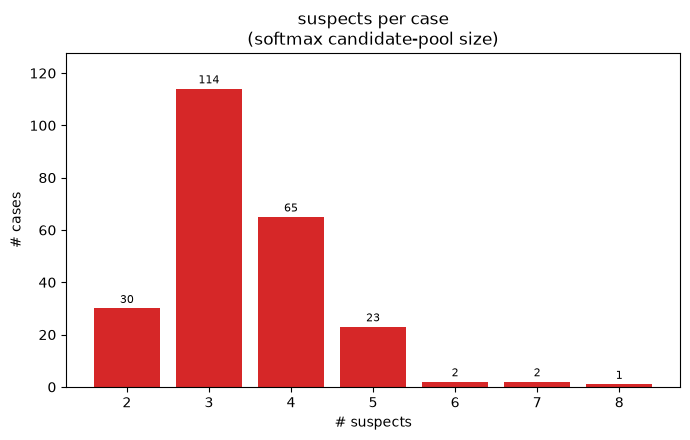

In [7]:
# --- viz: suspects per case (softmax candidate-pool size) ------------------
sc = stats["n_suspects"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(sc.index, sc.values, color="tab:red")
ax.bar_label(bars, padding=2, fontsize=8)
ax.set_title("suspects per case\n(softmax candidate-pool size)")
ax.set_xlabel("# suspects"); ax.set_ylabel("# cases")
ax.set_xticks(sc.index)
ax.margins(y=0.12)
plt.tight_layout()
plt.show()


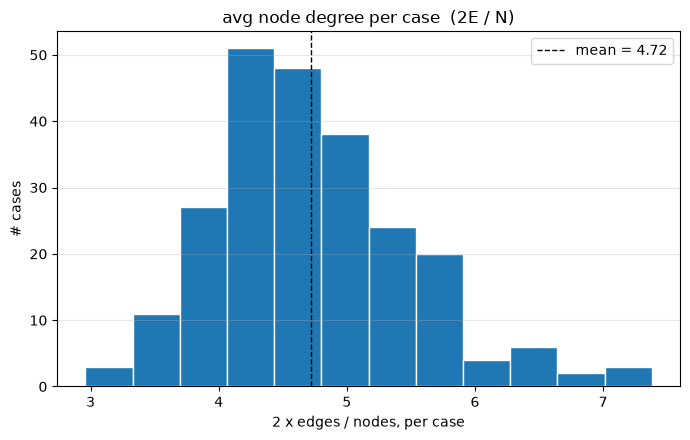

In [8]:
# --- viz: avg node degree per case (2E / N) ---------------------------------
mean_deg = stats["avg_degree"].mean()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(stats["avg_degree"], bins=12, color="tab:blue", edgecolor="white")
ax.axvline(mean_deg, color="black", linestyle="--", linewidth=1, label=f"mean = {mean_deg:.2f}")
ax.set_title("avg node degree per case  (2E / N)")
ax.set_xlabel("2 x edges / nodes, per case"); ax.set_ylabel("# cases")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Person role distribution

A person node can hold more than one role (e.g. a `victim` who is also a
`backstory_figure`), so these counts don't sum to the number of person
nodes.


In [9]:
# --- person role distribution ---------------------------------------------
role_counter = Counter()
for c in cases:
    for p in c["nodes"]["persons"]:
        role_counter.update(p.get("roles", []))

for r, n in role_counter.most_common():
    print(f"  {r:18s} {n:4d}")


  suspect             811
  witness             404
  victim              384
  backstory_figure    264
  bystander            85
  client                1
  investigator          1


### Edge catalogue

Two different numbers show up later and it's worth being precise about why
they differ:

- **raw `type` values** — the literal `edges[i]["type"]` string (`kills`,
  `owns`, `was_at`, `relationship`, ...). Counted directly below.
- **collapsed keys** — the loader's `_edge_relation_key` folds every
  `relationship` edge (regardless of `relation_type`) into one generic
  `relationship` key. The ~270 distinct `relation_type` values (`classmate`,
  `spouse_of`, ...) are real and still readable off the raw JSON, but the
  loader no longer exposes them as separate vocab entries -- they're too
  many for a relation-specific weight matrix to learn anything useful from
  individually. So the collapsed key space is *smaller* than raw types, not
  bigger: `(raw types − 1 for "relationship") + 1`.


In [10]:
# --- edge catalogue: raw types vs relation_type sub-types ------------------
edge_type_counter = Counter()
relation_type_counter = Counter()
for c in cases:
    for e in c["edges"]:
        edge_type_counter[e["type"]] += 1
        if e.get("relation_type"):
            relation_type_counter[e["relation_type"]] += 1

n_singleton_types = sum(1 for v in edge_type_counter.values() if v == 1)
collapsed_universe = len(edge_type_counter) - 1 + 1  # drop raw "relationship", add back one flat key

print(f"unique raw edge 'type' verbs: {len(edge_type_counter)}  "
      f"({n_singleton_types} appear in only 1 edge -- long tail)")
print(f"unique relation_type values folded away (no longer separate vocab entries): {len(relation_type_counter)}")
print(f"collapsed key space ({len(edge_type_counter)} - 1 + 1): {collapsed_universe}")
print("\ntop 12 raw edge types by frequency:")
for t, n in edge_type_counter.most_common(12):
    print(f"  {t:22s} {n:5d}")


unique raw edge 'type' verbs: 623  (389 appear in only 1 edge -- long tail)
unique relation_type values folded away (no longer separate vocab entries): 271
collapsed key space (623 - 1 + 1): 623

top 12 raw edge types by frequency:
  was_at                  2990
  relationship            1343
  implicates              1323
  regarding               1294
  owns                     676
  has_motive_against       599
  located_in               464
  kills                    288
  leaves_evidence          271
  stages_alibi_using       210
  confronts                116
  steals                    73


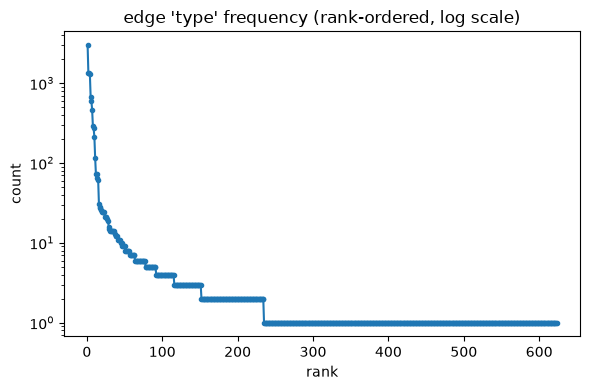

In [11]:
# --- viz: edge 'type' frequency long tail (log scale) ----------------------
freqs = sorted(edge_type_counter.values(), reverse=True)
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(freqs) + 1), freqs, marker=".")
plt.yscale("log")
plt.title("edge 'type' frequency (rank-ordered, log scale)")
plt.xlabel("rank"); plt.ylabel("count")
plt.tight_layout()
plt.show()


### Example case: reading one graph before trusting the aggregate stats

`ep011` ("Moonlight Sonata Murder Case") is the running example case —
persons colored red if tagged `suspect`, blue otherwise, with the
murderer's name marked. Layout: node positions are computed on a
de-duplicated simple graph so pairs joined by many parallel edges don't
collapse into an unreadable clump; every original (possibly parallel) edge
is still drawn. This is the **original** version — it's redrawn again after
the leak-removal step below so the two can be compared.


case: Moonlight Sonata Murder Case
persons=12 suspects=8 locations=5 objects=8 clues=2 edges=98
murderer: Narumi Asai  (p8)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


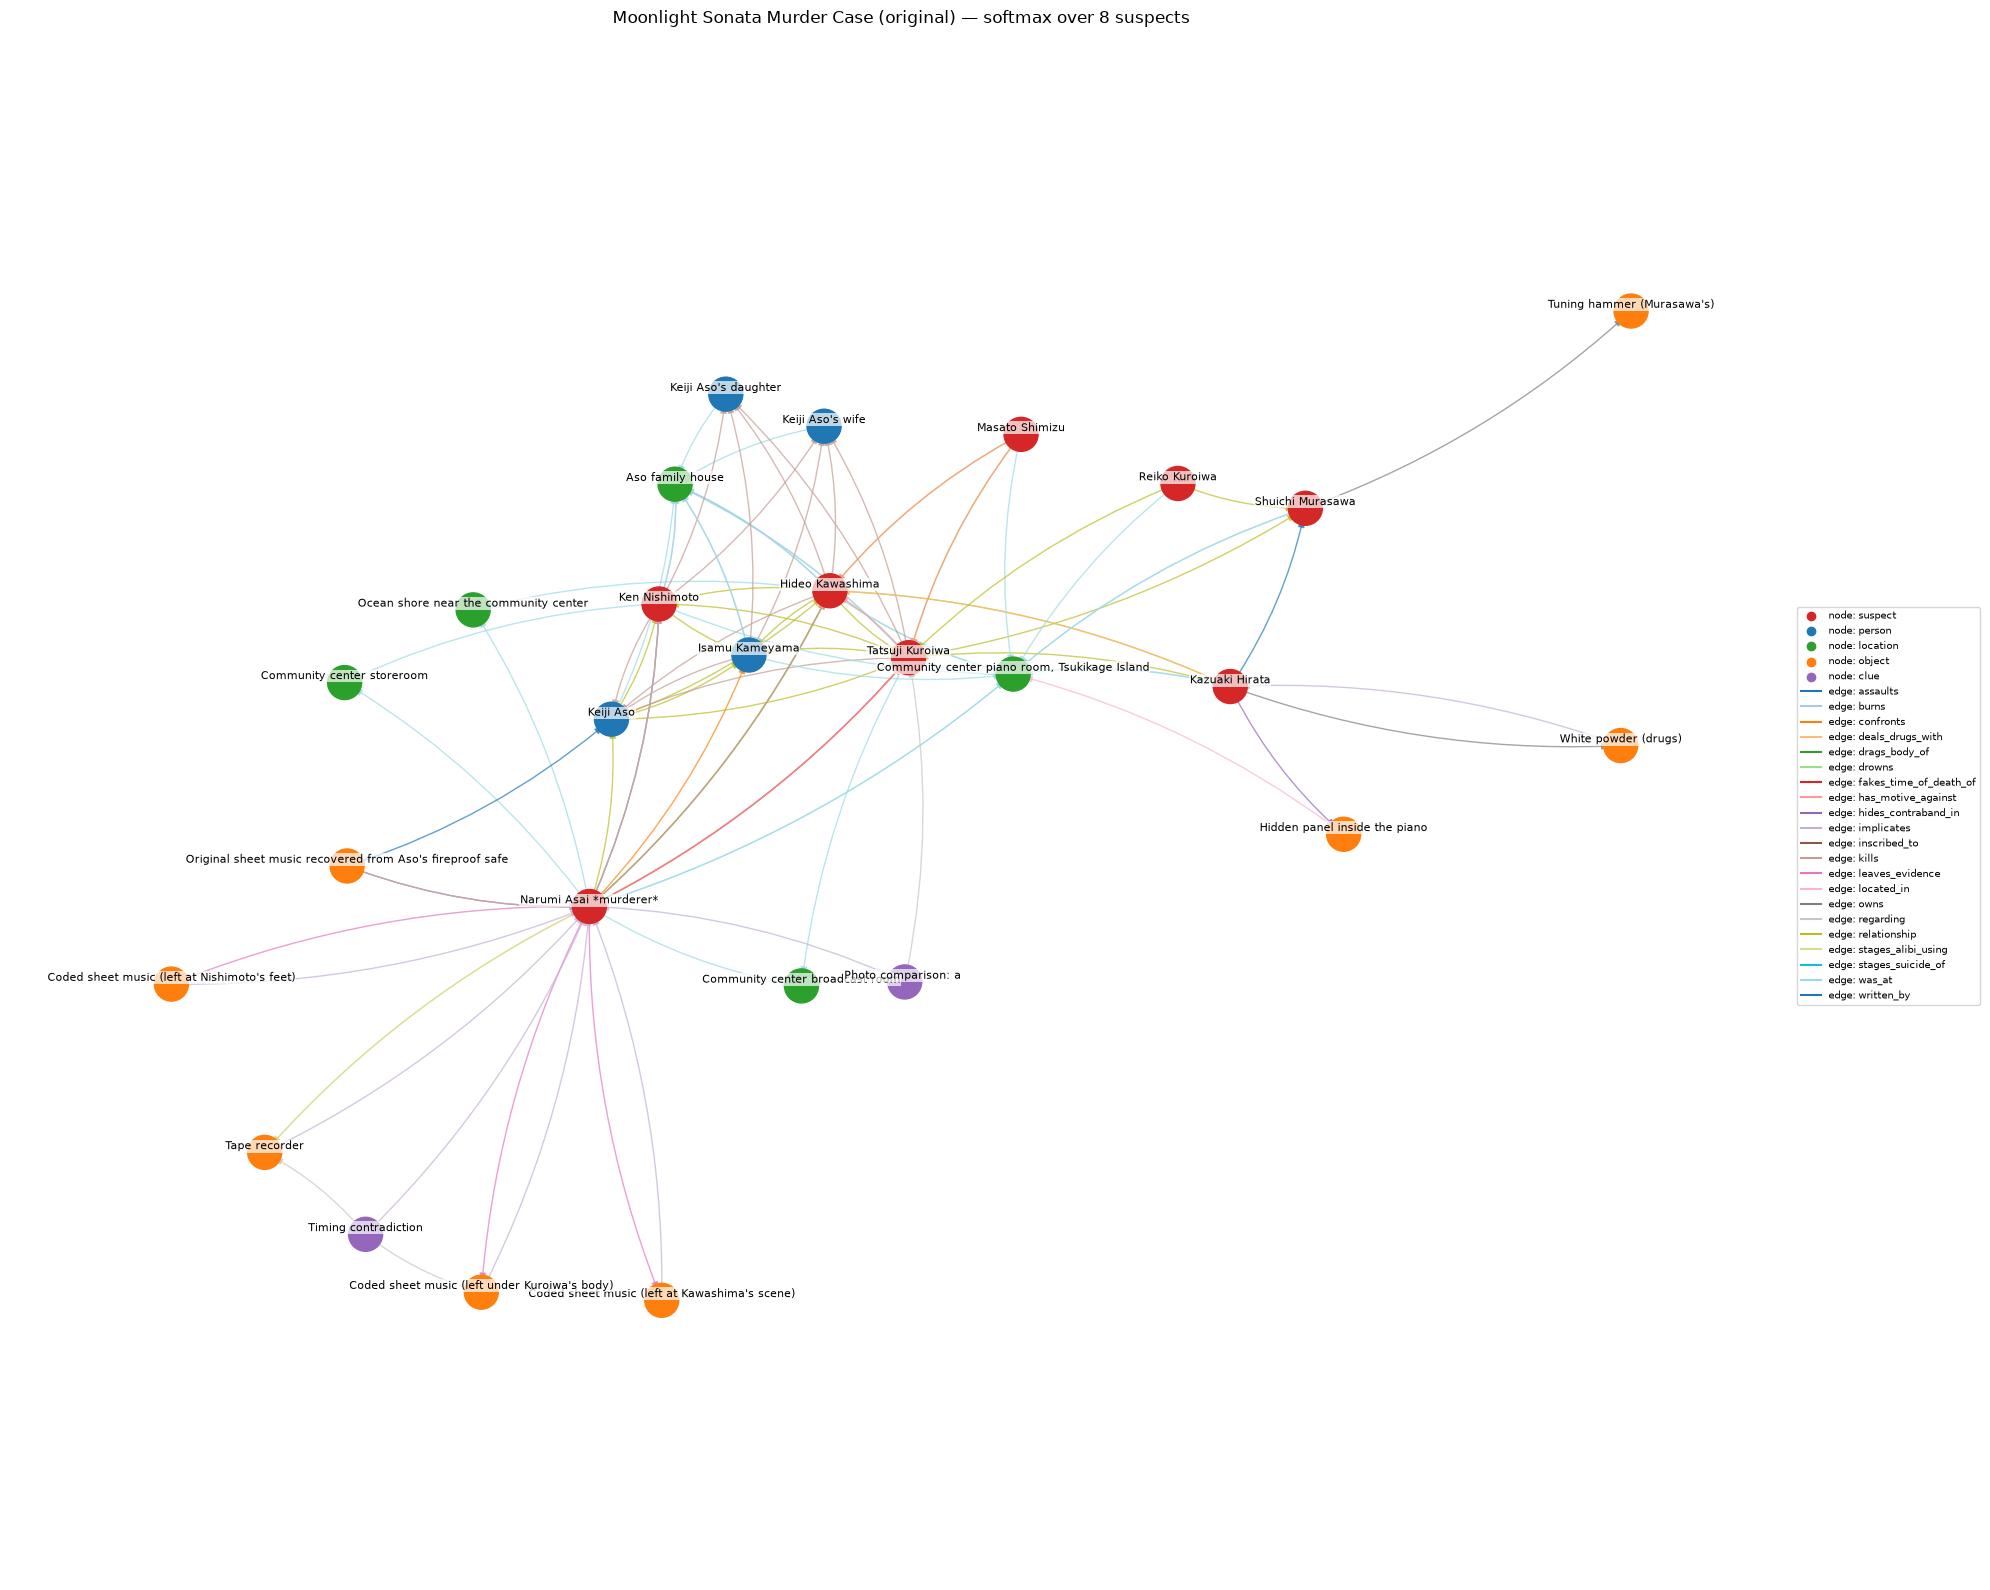

In [12]:
# --- visualize moonlight sonata (original) ----------------------------------
from visualize_case import load_case as load_case_for_viz, draw_case

example_path = os.path.join(DATA_ROOT, "ep011_moonlight_sonata_murder_case.json")
example = load_case_for_viz(example_path)

ex_persons = example["nodes"]["persons"]
ex_suspects = [p for p in ex_persons if "suspect" in p.get("roles", [])]
ex_murderer_id = example["label"]["murderer_id"]
ex_murderer = next(p for p in ex_persons if p["id"] == ex_murderer_id)

print(f"case: {example['title']}")
print(f"persons={len(ex_persons)} suspects={len(ex_suspects)} "
      f"locations={len(example['nodes']['locations'])} "
      f"objects={len(example['nodes']['objects'])} "
      f"clues={len(example['nodes']['clues'])} edges={len(example['edges'])}")
print(f"murderer: {ex_murderer['name']}  ({ex_murderer_id})")

draw_case(example, title=f"{example['title']} (original) — softmax over {len(ex_suspects)} suspects")


### Leak audit: which edge types "give away" the murderer?

Some edges only exist in the graph *because* the story's solution already
happened — e.g. a `kills` or `stages_alibi_using` edge is authored by
someone who already knows who did it. A GNN trained on those edges wouldn't
be learning detective reasoning, it would be reading the answer key.

**Metric.** For every edge key (top-level `type`, or `relation_type` for
`relationship` edges), and for every case, find which **suspect** nodes
that key touches (as `from` or `to`) — restricted to suspects because
that's the softmax candidate pool the model actually chooses between. Note
that "touches a suspect" says nothing about what's on the *other* end of
the edge — the other endpoint can just as easily be an object, a location,
or a clue as another person (`owns` connects a suspect to an *object*,
`hides_contraband_in` to a *location*, `implicates` to an *object or
clue*). Then define a single **concentration score**:

```
concentration(key) = murderer_touches(key) / (murderer_touches(key) + other_suspect_touches(key))
```

i.e. *of every suspect this edge key ever touches, what fraction are the
murderer.* Bounded in **[0, 1]**:

- **≈ base rate (murderers / all suspects, ≈0.29 in this corpus)** → no
  signal — the edge type is no more likely to touch the murderer than to
  touch anyone else.
- **→ 1.0** → almost every suspect this edge type ever touches turns out to
  be the murderer — a giveaway.

**Minimum support.** Only edge keys that touch the **murderer in at least
10 different cases** are scored — a key seen touching the murderer once or
twice and never anyone else would otherwise score a meaningless 1.0.

**Sanity check to watch for below:** `was_at` (pure location co-presence,
about as uninformative as an edge type gets here) should land close to the
~0.29 base rate — an uninformative edge type should score near baseline,
not near 0 or 1.

**Threshold: 0.65.** `relationship` edges (one collapsed key, regardless of
`relation_type`) are never auto-excluded no matter their score — they
encode *pre-existing* social facts (motive signal a real detective is
allowed to use). Among `action` keys (`kills`, `owns`, ...), concentration
≥ 0.65 means removal: mostly *what happened during the crime*, i.e.
post-hoc narration only the killer/narrator would know.


In [13]:
# --- leaks: compute per-key touch counts -----------------------------------
murderer_touch = Counter()          # key -> # cases where the murderer is touched
other_touch = Counter()             # key -> # (case, non-murderer-suspect) pairs touched
case_support = defaultdict(set)     # key -> set of case_ids where key touches ANY suspect

for c in cases:
    persons = c["nodes"]["persons"]
    suspect_ids = {p["id"] for p in persons if "suspect" in p.get("roles", [])}
    murderer_id = c["label"]["murderer_id"]
    other_ids = suspect_ids - {murderer_id}

    touched_by = defaultdict(set)   # key -> suspect ids touched, this case
    for e in c["edges"]:
        key = _edge_relation_key(e)   # 'kills', 'owns', ... or 'rel:classmate', ...
        for endpoint in (e["from"], e["to"]):
            if endpoint in suspect_ids:
                touched_by[key].add(endpoint)

    for key, ids in touched_by.items():
        case_support[key].add(c["case_id"])
        if murderer_id in ids:
            murderer_touch[key] += 1
        other_touch[key] += len(ids & other_ids)

print(f"{len(case_support)} distinct edge keys touch at least one suspect")


512 distinct edge keys touch at least one suspect


In [14]:
# --- leaks: concentration score + thresholding ------------------------------
MIN_MURDERER_SUPPORT = 10   # only score keys that touch the murderer in >=10 cases.
                             # (Verbs with fewer touches than this -- e.g. `strangles`,
                             # `orders` -- are reviewed manually below instead of being
                             # auto-flagged: at n<10 the concentration score is too noisy to
                             # threshold on its own -- see the manual-review section.)
EXCLUDE_THRESHOLD = 0.65    # action-verb edges >= this: confident post-hoc-narration leak

base_rate = n_cases / total_suspects  # reference line: "no signal" concentration

leak_rows = []
for key, cids in case_support.items():
    m, o = murderer_touch[key], other_touch[key]
    if m < MIN_MURDERER_SUPPORT:
        continue
    concentration = m / (m + o)
    leak_rows.append(dict(
        edge_key=key, category="relationship" if key == "relationship" else "action",
        support_cases=len(cids), murderer_touches=m, other_suspect_touches=o,
        murderer_rate=m / n_cases, other_suspect_rate=o / (total_suspects - n_cases),
        concentration=concentration,
    ))

leak_df = pd.DataFrame(leak_rows).sort_values("concentration", ascending=False).reset_index(drop=True)
print(f"base rate (murderers / all suspects): {base_rate:.3f}")
print(f"{len(leak_df)} edge keys with murderer support >= {MIN_MURDERER_SUPPORT}")
leak_df


base rate (murderers / all suspects): 0.292
29 edge keys with murderer support >= 10


,edge_key,category,support_cases,murderer_touches,other_suspect_touches,murderer_rate,other_suspect_rate,concentration
0,poisons,action,20,19,1,0.080169,0.001742,0.950000
1,stages_alibi_using,action,118,115,7,0.485232,0.012195,0.942623
2,drags_body_of,action,23,23,2,0.097046,0.003484,0.920000
3,wears,action,11,10,1,0.042194,0.001742,0.909091
4,uses,action,41,39,4,0.164557,0.006969,0.906977
5,hides_contraband_in,action,18,16,2,0.067511,0.003484,0.888889
6,kills,action,192,191,25,0.805907,0.043554,0.884259
7,drugs,action,14,14,2,0.059072,0.003484,0.875000
8,leaves_evidence,action,128,125,19,0.527426,0.033101,0.868056
9,stages_suicide_of,action,26,25,4,0.105485,0.006969,0.862069


In [15]:
# --- leaks: which keys cross the 0.65 threshold -----------------------------
over_threshold = (leak_df["category"] == "action") & (leak_df["concentration"] >= EXCLUDE_THRESHOLD)
exclude_list = leak_df[over_threshold]

print(f"{len(exclude_list)} of {len(leak_df)} edge keys are >= {EXCLUDE_THRESHOLD} concentration")
leak_df


19 of 29 edge keys are >= 0.65 concentration


,edge_key,category,support_cases,murderer_touches,other_suspect_touches,murderer_rate,other_suspect_rate,concentration
0,poisons,action,20,19,1,0.080169,0.001742,0.950000
1,stages_alibi_using,action,118,115,7,0.485232,0.012195,0.942623
2,drags_body_of,action,23,23,2,0.097046,0.003484,0.920000
3,wears,action,11,10,1,0.042194,0.001742,0.909091
4,uses,action,41,39,4,0.164557,0.006969,0.906977
5,hides_contraband_in,action,18,16,2,0.067511,0.003484,0.888889
6,kills,action,192,191,25,0.805907,0.043554,0.884259
7,drugs,action,14,14,2,0.059072,0.003484,0.875000
8,leaves_evidence,action,128,125,19,0.527426,0.033101,0.868056
9,stages_suicide_of,action,26,25,4,0.105485,0.006969,0.862069


### Manual review: leaks below the automatic support gate

`MIN_MURDERER_SUPPORT=10` is deliberately conservative -- at low support the
concentration score is too noisy to threshold on automatically (a verb used
once that happens to touch the murderer scores a meaningless 1.0). Below
that gate, verbs were checked by hand against their narration text instead
of just trusting the statistic.

**Kept as automatic-only (not manually added):** the bulk of the long tail
(224 of 299 candidates below the gate touch the murderer in exactly 1 case)
is exactly this kind of noise and was left alone -- e.g. `confides_in`,
`retrieves`, `cuts_hair_of`. No plausible causal link to guilt, just a small
sample landing on the murderer once by chance.

**Added by hand, checked against the actual narration:**
- murder-method / scene-tampering verbs with enough repetition to trust
  even below n=10: `stabs`, `drowns`, `strangles`, `wields`, `conceals`,
  `discards`, `destroys_evidence`, `conceals_evidence_using`, `disposes_of`,
  `plants`, `disguises_as`, `forges`, `rigs`, `relocates`,
  `stages_accident_of`, `inscribed_to`, `confesses_to`.
- `installs` -- initially looked like sample-size noise (support=6, no
  obvious link to guilt), but checking the actual instances: 4 of 6 are
  literally rigging the murder-trap mechanism itself (e.g. ep124-125:
  "rigs a gun with a motor-and-string trigger onto one of the stage
  lights, wired to fire via remote..."). Genuine leak, not noise.
- `arrests` / `surrenders` -- not narration-leak in the usual sense, but a
  structural tautology: the story always ends with the actual murderer
  being the one who gets arrested or surrenders, by construction of "case
  closed."
- `exonerates` -- leaks in the *opposite* direction (concentration 0.0, not
  >= 0.65): an exonerated suspect is by definition not the murderer, which
  is exactly as much of an answer as a high-concentration verb. Included
  even though it would never trip the one-sided >= 0.65 threshold on its
  own.

**Left alone on purpose:** `detains` (0.50) and `apprehends` (0.50) sit
right at a coin flip -- no signal, no reason to remove.


In [16]:
MANUAL_EXCLUDE = {
    "rigs", "disposes_of", "drowns", "plants", "confesses_to",
    "stages_accident_of", "destroys_evidence", "conceals_evidence_using",
    "conceals", "strangles", "installs", "wields", "stabs", "discards",
    "inscribed_to", "forges", "disguises_as", "relocates",
    "arrests", "surrenders", "exonerates",
}
print(f"{len(MANUAL_EXCLUDE)} manually-added edge types")


21 manually-added edge types


### Remove the leaked edge types and export a cleaned dataset

This is the concrete data-quality fix, not just an audit: every edge whose
**type** cleared the EXCLUDE bar (concentration ≥ 0.65) is dropped from
**every** case in the corpus — the edge *type* is removed wholesale, not
just its suspect-touching instances. (In practice this is exactly
`exclude_list` above — no `relationship` sub-type reaches 0.65 in this
corpus, so category-restricting it or not makes no difference here, but the
category rule stays in the code as the actual safeguard.) Nodes are left
untouched; only edges are dropped, so node counts before/after are
unchanged even where edge counts drop a lot.

The cleaned cases are written out as a new dataset version, **`cases_v4`**
(schema-version bump; unrelated to this notebook being "v5"), saved next to
this notebook at `Reo analysis/v5/cases_v4/`.


In [17]:
# --- remove all edges of every EXCLUDE-tier type, corpus-wide --------------
EXCLUDED_KEYS = set(exclude_list["edge_key"]) | MANUAL_EXCLUDE

removed_edge_counts = Counter()   # key -> # edges removed, corpus-wide
cleaned_cases = []
for c in cases:
    kept_edges = []
    for e in c["edges"]:
        key = _edge_relation_key(e)
        if key in EXCLUDED_KEYS:
            removed_edge_counts[key] += 1
        else:
            kept_edges.append(e)
    cleaned = dict(c)          # shallow copy: only "edges" changes below
    cleaned["edges"] = kept_edges
    cleaned["schema_version"] = "v4"
    cleaned_cases.append(cleaned)

total_removed = sum(removed_edge_counts.values())
total_kept = sum(len(c["edges"]) for c in cleaned_cases)
total_original = total_removed + total_kept

print(f"removing {len(EXCLUDED_KEYS)} edge types: {sorted(EXCLUDED_KEYS)}")
print(f"\nremoved {total_removed} edges corpus-wide, {total_kept} remain "
      f"({total_removed / total_original:.1%} of all {total_original} edges)")


removing 40 edge types: ['arrests', 'burns', 'conceals', 'conceals_evidence_using', 'confesses_to', 'destroys_evidence', 'discards', 'disguises_as', 'disposes_of', 'drags_body_of', 'drowns', 'drugs', 'exonerates', 'fakes_time_of_death_of', 'forges', 'hides_contraband_in', 'impersonates', 'implicates', 'inscribed_to', 'installs', 'kills', 'leaves_evidence', 'lures', 'plants', 'poisons', 'relocates', 'rigs', 'sabotages', 'stabs', 'stages_accident_of', 'stages_alibi_using', 'stages_suicide_of', 'steals', 'strangles', 'surrenders', 'tampers_with', 'uses', 'wears', 'wields', 'written_by']

removed 2714 edges corpus-wide, 8715 remain (23.7% of all 11429 edges)


In [18]:
# --- write the cleaned cases_v4 dataset -------------------------------------
OUT_DIR = os.path.join(os.getcwd(), "cases_v4")
os.makedirs(OUT_DIR, exist_ok=True)

for cleaned in cleaned_cases:
    out_path = os.path.join(OUT_DIR, f"{cleaned['case_id']}.json")
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(cleaned, f, indent=2, ensure_ascii=False)

print(f"wrote {len(cleaned_cases)} cleaned case files to {OUT_DIR}")
print(f"(single-suspect cases dropped earlier are not included: {len(single_suspect_cases)} fewer files than the raw cases_v3 corpus)")


wrote 237 cleaned case files to /home/reo/Faks/GNN/2.0/Reo analysis/v5/cases_v4
(single-suspect cases dropped earlier are not included: 10 fewer files than the raw cases_v3 corpus)


### Moonlight Sonata, again — after cleaning

Same case, same layout function, but drawn straight from `cleaned_cases`
(not re-loaded from disk) so this is exactly what the exported `cases_v4`
file for `ep011` looks like. Compare against the "original" render above:
same nodes, fewer edges — every `kills`, `stages_alibi_using`,
`leaves_evidence`, `implicates`, ... edge is gone, along with the other 15
EXCLUDE-tier types.


case: Moonlight Sonata Murder Case
edges before cleaning: 98   after: 60


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


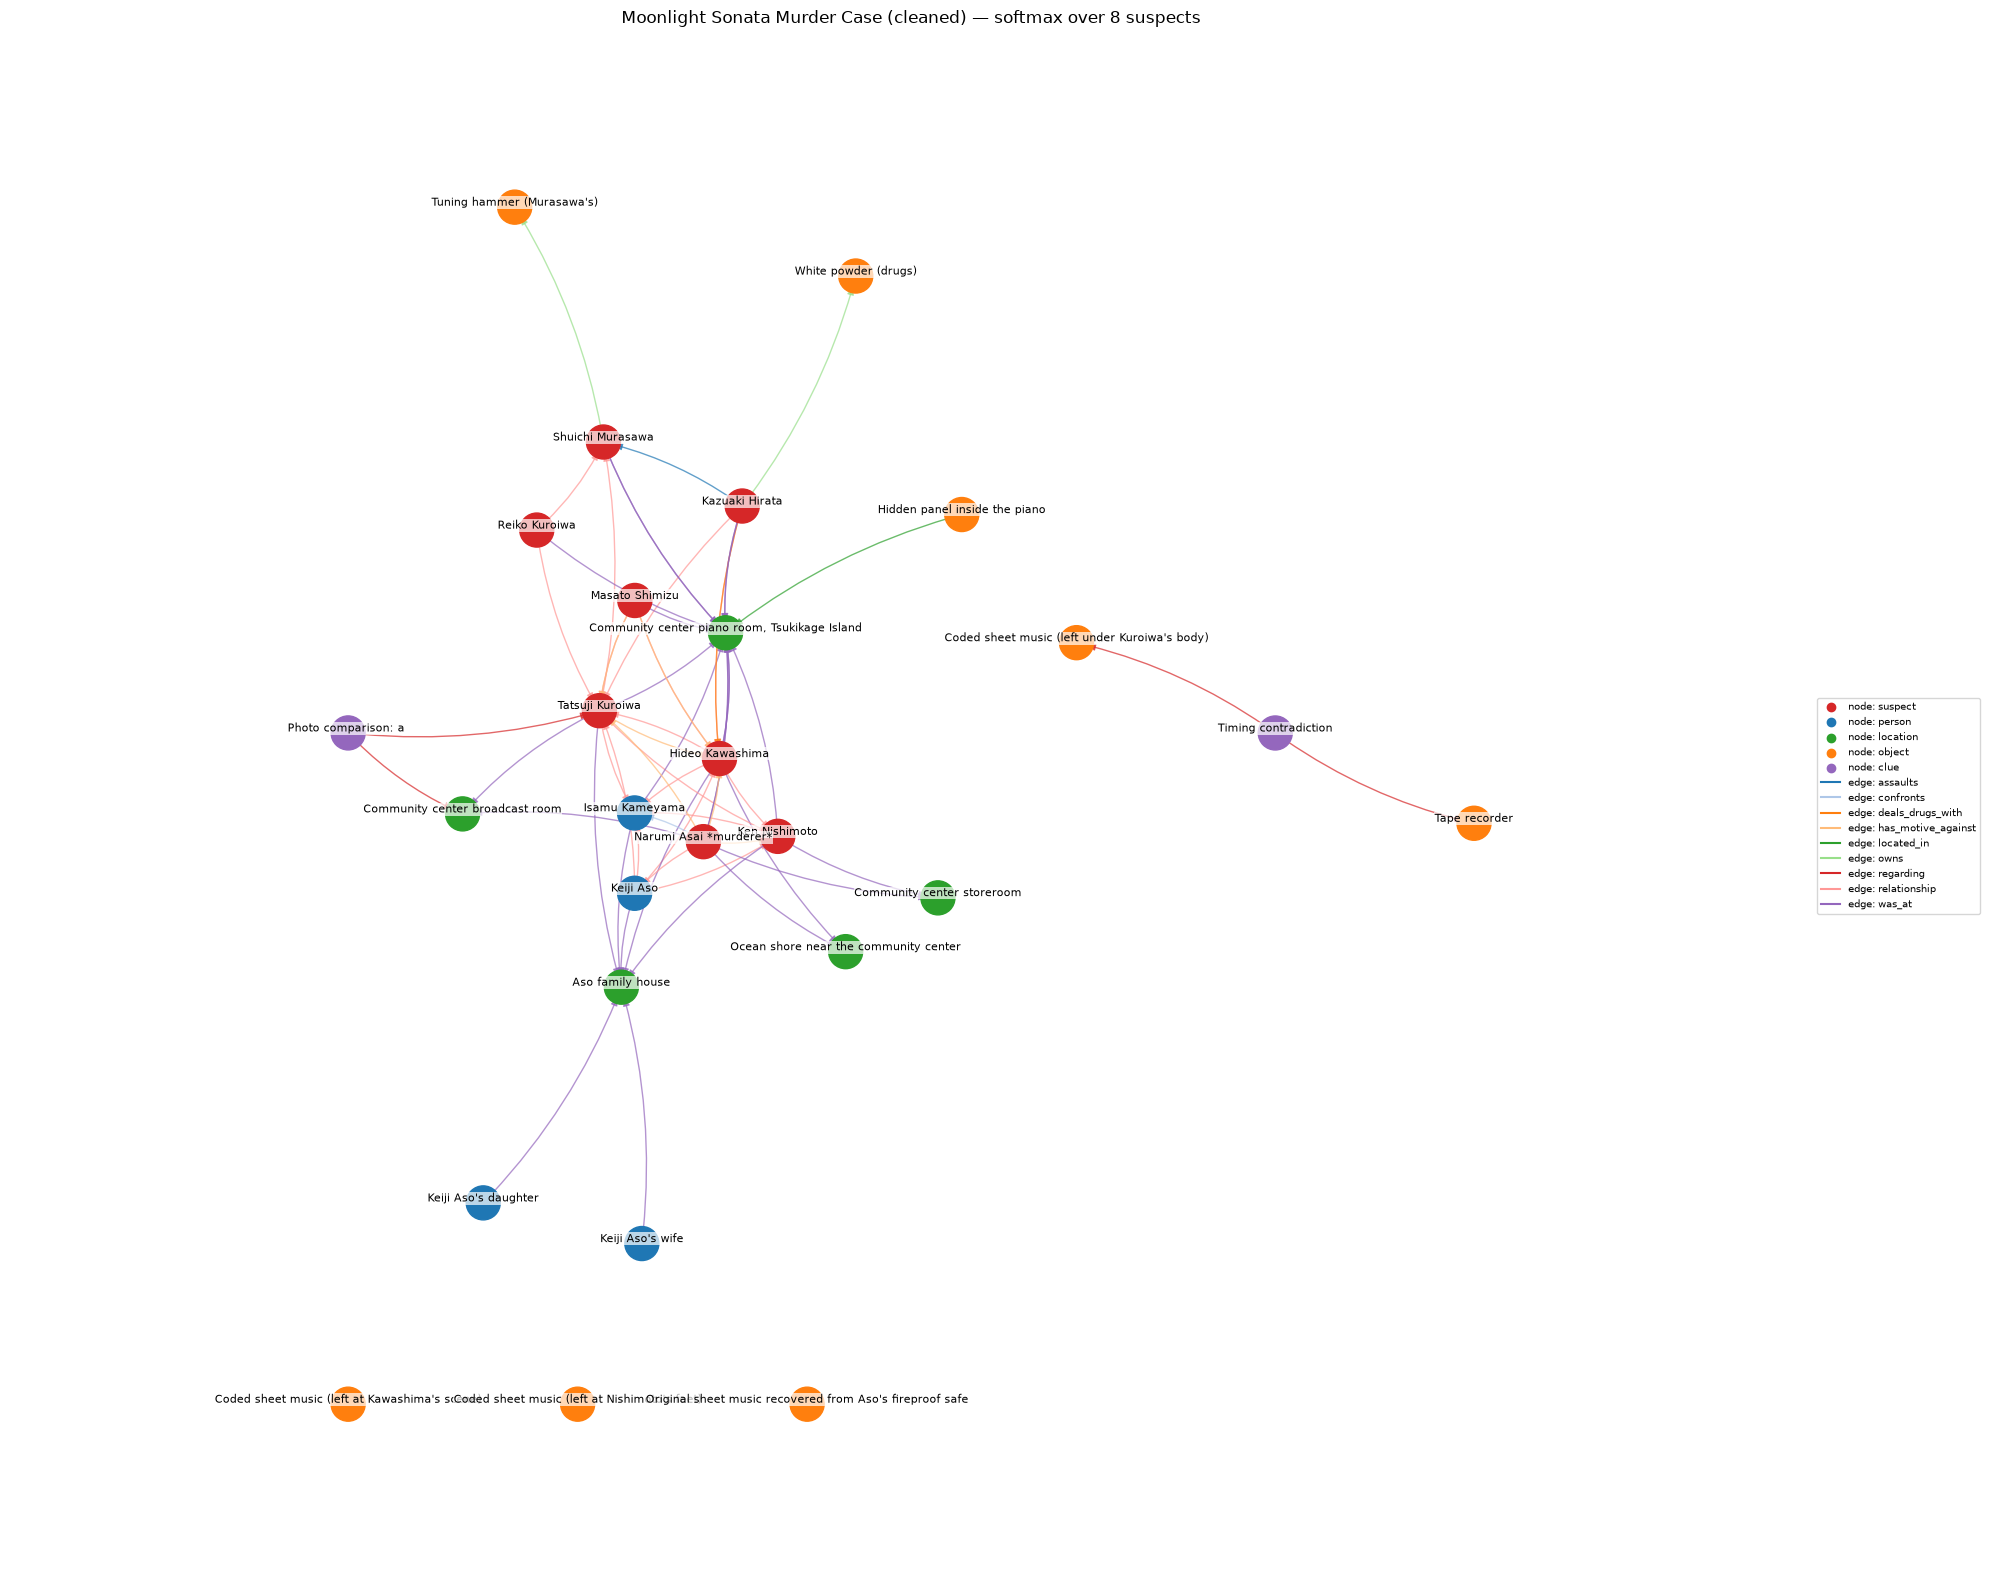

In [19]:
# --- visualize moonlight sonata (cleaned) -----------------------------------
example_clean = next(c for c in cleaned_cases if c["case_id"] == "ep011_moonlight_sonata_murder_case")

print(f"case: {example_clean['title']}")
print(f"edges before cleaning: {len(example['edges'])}   after: {len(example_clean['edges'])}")

draw_case(example_clean, title=f"{example_clean['title']} (cleaned) — softmax over {len(ex_suspects)} suspects")


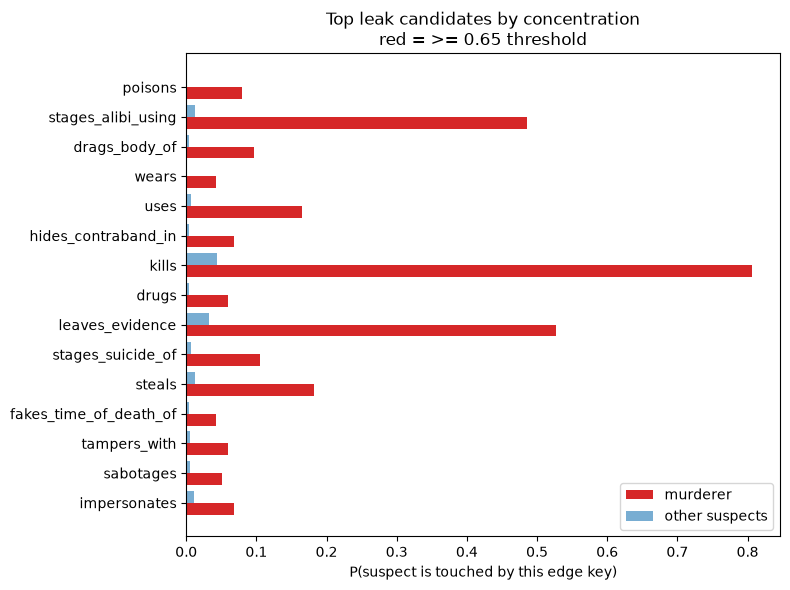

In [20]:
# --- viz: murderer-rate vs other-suspect-rate for the top leak candidates --
top = leak_df.head(15).iloc[::-1]
top_over = (top["category"] == "action") & (top["concentration"] >= EXCLUDE_THRESHOLD)
colors = ["tab:red" if over else "tab:gray" for over in top_over]

fig, ax = plt.subplots(figsize=(8, 6))
y = np.arange(len(top))
ax.barh(y - 0.2, top["murderer_rate"], height=0.4, color=colors, label="murderer")
ax.barh(y + 0.2, top["other_suspect_rate"], height=0.4, color="tab:blue", alpha=0.6, label="other suspects")
ax.set_yticks(y); ax.set_yticklabels(top["edge_key"])
ax.set_xlabel("P(suspect is touched by this edge key)")
ax.set_title(f"Top leak candidates by concentration\nred = >= {EXCLUDE_THRESHOLD} threshold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


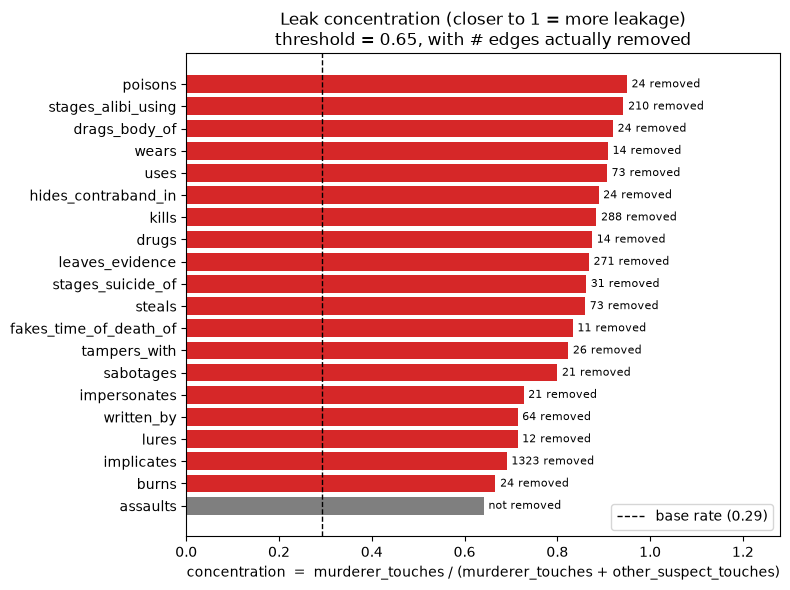

In [21]:
# --- viz: concentration score (0-1) + how many edges were actually removed -
top_conc = leak_df.head(20).iloc[::-1].copy()
top_conc["removed"] = top_conc["edge_key"].map(removed_edge_counts).fillna(0).astype(int)
top_over = (top_conc["category"] == "action") & (top_conc["concentration"] >= EXCLUDE_THRESHOLD)
colors = ["tab:red" if over else "tab:gray" for over in top_over]

fig, ax = plt.subplots(figsize=(8, 6))
y = np.arange(len(top_conc))
bars = ax.barh(y, top_conc["concentration"], color=colors)
ax.axvline(base_rate, color="black", linestyle="--", linewidth=1, label=f"base rate ({base_rate:.2f})")

# label each bar with how many edges of that type were removed corpus-wide
for bar, removed, over in zip(bars, top_conc["removed"], top_over):
    label = f"{removed} removed" if over else "not removed"
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, label,
            va="center", fontsize=8)

ax.set_yticks(y); ax.set_yticklabels(top_conc["edge_key"])
ax.set_xlim(0, 1.28)
ax.set_xlabel("concentration  =  murderer_touches / (murderer_touches + other_suspect_touches)")
ax.set_title(f"Leak concentration (closer to 1 = more leakage)\nthreshold = {EXCLUDE_THRESHOLD}, with # edges actually removed")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [22]:
# --- persist the leak table (now including removed-edge counts) ------------
leak_df["edges_removed"] = leak_df["edge_key"].map(removed_edge_counts).fillna(0).astype(int)

out_path = "leak_candidates_v5.csv"
leak_df.to_csv(out_path, index=False)
print(f"saved {len(leak_df)} rows to {out_path}")


saved 29 rows to leak_candidates_v5.csv


### Findings

- **Sanity check passed:** `was_at` scores concentration **0.300**,
  essentially identical to the corpus base rate (**0.292**) — the
  calibration check for the whole metric.
- **`poisons` (0.95), `stages_alibi_using` (0.94), `drags_body_of` (0.92)**
  are the strongest leaks. `kills` sits at **0.88** (216 touches, 191 the
  murderer). `implicates` scores lower (0.69) but has the highest raw
  volume of any key (343 touches, 237/237 cases) — still one of the most
  dangerous single edges in the corpus purely on reach.
- **19 edge types removed automatically (support ≥ 10, concentration ≥ 0.65),
  2,548 of 11,429 edges (22.3%).** `implicates` alone accounts for 1,323 of
  those — over half — followed by `kills` (288) and `leaves_evidence` (271).
  `ep011` (Moonlight Sonata) goes from 98 to 62 edges after cleaning, visible
  in the before/after renders above.
- `owns`, `assaults`, `confronts`, `blackmails`, `threatens`, and `frames`
  score between 0.48 and 0.64 — elevated but under the 0.65 line, so they
  were **kept**. `has_motive_against` (0.43) scores even lower and was never
  a candidate — motive is signal a real detective is allowed to use.
  `relationship` edges are exempt from removal by category, not by score, so
  they were never scored individually here either way.
- **+ 21 more removed by hand below the support gate** (`stabs`, `drowns`,
  `strangles`, `installs`, `arrests`, `surrenders`, `exonerates`, ...) — see
  "Manual review" below for why each one is a real leak and not sample-size
  noise. **Final count: 40 edge types removed, 2,714 of 11,429 edges (23.7%).**

**On the graph falling apart into pieces:** stripping `implicates`, `kills`,
`owns`-adjacent action edges, etc. leaves a few evidence nodes (e.g. some
"coded sheet music" objects in `ep011`) with no edges left at all — visible
in the cleaned render above as small clusters or single dots off to the
side, no longer connected to the main graph. That's expected and not a bug:
those objects only existed in the story because they were narrated as
pointing at the killer, so removing the narration-only edges naturally
disconnects them, and message passing simply won't reach them for that
case — the same way a real detective doesn't get to link every piece of
evidence they collect. It's a genuine limitation worth naming explicitly in
the report, not something to quietly patch by deleting the now-isolated
nodes here: a future iteration could try giving every object/clue a
non-leaky fallback edge (e.g. to the location it was found in), but that's
a modeling decision for later, not a data-cleaning step.

**Still open (next steps, not covered in this notebook):** the
`relation_type`/action-verb bucket taxonomy started below, and the
case-level, suspect-count-stratified train/val/test split. The exported
`cases_v4` dataset is what GNN v2 (the "clean data" iteration in the wider
plan) should train against, compared back to a v1 model trained on the
original `cases_v3`.


## 3. Train / val / test split, baseline, and GNN

Everything below trains on **`cleaned_cases`** — the leak-audited corpus
from above, not the raw `cases_v3` — since training on the raw data would
let both models trivially "solve" the task via `kills`/`implicates`/etc.
and defeat the point of the audit. Bucketing (Section 4, further down) is
deliberately done *after* this, not before: it's a refinement to the input
vocabulary, not something the split/baseline/GNN protocol depends on.

### 3a. Split: grouped, stratified 5-fold CV

**Why not one 80/20 split?** 237 cases → a single held-out test set is
~47 cases. That's small enough that the reported accuracy could swing
several points just from *which* cases happened to land in test — not a
number you'd want to defend in a viva. **5-fold CV** trains and evaluates 5
times on 5 different held-out slices and reports mean ± std, which is a far
more trustworthy number than one lucky (or unlucky) split.

**Split unit = case, not suspect-row.** All suspect rows from the same case
must end up on the same side of every split. They share the case's clues,
locations, and edges — if two suspects from the same case landed on
opposite sides, information about that case (and indirectly about its
murderer) would leak across the split. Concretely: each case is exactly one
"group," so a per-case split already keeps every suspect-row from that case
together automatically — the grouping constraint is satisfied by
construction once the split happens at the case level rather than the row
level.

**Stratified by suspect-count bucket** — the same `n_suspects` variable
used throughout this notebook — so each fold sees a similar mix of "easy"
(2-3 suspect) and "hard" (many-suspect) cases, not by chance an unlucky
fold that's all 2-suspect cases. The rare tail (6, 7, 8 suspects — 5, 2, 1
cases respectively) is bucketed together as "6+" so every stratum has
enough members for 5-fold splitting to work at all.

**Per fold:** the held-out 20% is the fold's **test** set; the remaining
80% is further split (85/15, same stratification) into **train** / **val**
— val is used for model selection (best-epoch checkpointing for the GNN),
test is touched exactly once, at the end, per fold.


In [23]:
# --- 5-fold grouped + stratified split, built once and reused by both models
from sklearn.model_selection import StratifiedKFold, train_test_split

N_FOLDS = 5
SPLIT_SEED = 42

def suspect_bucket(case):
    return min(n_suspects(case), 6)  # 6 stands for "6 or more" -- keeps every stratum >= 5 cases

clean_case_ids = np.array([c["case_id"] for c in cleaned_cases])
clean_buckets = np.array([suspect_bucket(c) for c in cleaned_cases])
print("suspect-bucket sizes:", dict(sorted(Counter(clean_buckets).items())))

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SPLIT_SEED)

folds = []
for fold_i, (trainval_idx, test_idx) in enumerate(skf.split(clean_case_ids, clean_buckets)):
    trainval_ids, trainval_buckets = clean_case_ids[trainval_idx], clean_buckets[trainval_idx]
    train_ids, val_ids = train_test_split(
        trainval_ids, test_size=0.15, stratify=trainval_buckets, random_state=SPLIT_SEED
    )
    folds.append(dict(train=set(train_ids), val=set(val_ids), test=set(clean_case_ids[test_idx])))
    print(f"fold {fold_i}: train={len(train_ids):3d}  val={len(val_ids):3d}  test={len(test_idx):3d}")

# sanity: within each fold, train/val/test are disjoint and cover every case exactly once
for f in folds:
    assert not (f["train"] & f["val"]) and not (f["train"] & f["test"]) and not (f["val"] & f["test"])
    assert len(f["train"] | f["val"] | f["test"]) == len(cleaned_cases)
print("\nsplit sanity OK: disjoint within each fold, every case covered")


suspect-bucket sizes: {np.int64(2): 30, np.int64(3): 114, np.int64(4): 65, np.int64(5): 23, np.int64(6): 5}
fold 0: train=160  val= 29  test= 48
fold 1: train=160  val= 29  test= 48
fold 2: train=161  val= 29  test= 47
fold 3: train=161  val= 29  test= 47
fold 4: train=161  val= 29  test= 47

split sanity OK: disjoint within each fold, every case covered


### 3b. Baseline: gradient-boosted trees, no graph structure

**Model:** `HistGradientBoostingClassifier` (scikit-learn) — a tree-ensemble
baseline for the flat, tabular feature vectors below (matches the earlier
plan note "GBT, learning to rank then taking top pick").

**Inputs — deliberately node-only.** Each suspect's feature vector is: a
multi-hot over their `roles`, whether `occupation` is present, and a
32-dim hashed bag-of-words over `name` + `occupation` + `aliases` + `attrs`
text. **No `edge_index`, no graph structure at all** — this is what the
"baseline bez grafa" requirement means, and it's also what makes the GNN
comparison meaningful: if the GNN beats this, the gap is attributable to
*structure* (motive/relationship/location edges), not to better node
features.

**"Learning to rank."** One pooled binary classifier is trained across
every suspect-row in the fold's training cases (target: is this suspect
the murderer?). At evaluation, within each *test* case, suspects are
ranked by predicted probability and the top-ranked one is the model's
guess — the same per-case top-1 decision the GNN's per-graph softmax head
produces, so both models are judged on identical terms.

Same 5-fold split as above; metrics are per-case **top-1 accuracy** and
**MRR** (mean reciprocal rank — how far down the ranking the true murderer
tends to land, secondary metric per the plan), reported as mean ± std
across the 5 folds.


In [24]:
# --- baseline: build one node-only feature row per suspect -----------------
from case_closed_dataset import _hash_bow, _flatten_text, TEXT_HASH_DIM

ROLE_VOCAB = sorted({r for c in cleaned_cases for p in c["nodes"]["persons"] for r in p.get("roles", [])})
role_index = {r: i for i, r in enumerate(ROLE_VOCAB)}
print(f"role vocab ({len(ROLE_VOCAB)}): {ROLE_VOCAB}")

suspect_rows, suspect_feats = [], []
for c in cleaned_cases:
    murderer_id = c["label"]["murderer_id"]
    for p in c["nodes"]["persons"]:
        if "suspect" not in p.get("roles", []):
            continue
        role_vec = np.zeros(len(ROLE_VOCAB))
        for r in p.get("roles", []):
            role_vec[role_index[r]] = 1.0
        text = _flatten_text(p.get("name"), p.get("occupation"), p.get("aliases"), p.get("attrs"))
        text_vec = np.array(_hash_bow(text))
        occ_present = 1.0 if p.get("occupation") else 0.0
        suspect_feats.append(np.concatenate([role_vec, [occ_present], text_vec]))
        suspect_rows.append(dict(case_id=c["case_id"], suspect_id=p["id"],
                                  is_murderer=int(p["id"] == murderer_id)))

suspect_df = pd.DataFrame(suspect_rows)
X_baseline = np.stack(suspect_feats)
print(f"\nsuspect rows: {len(suspect_df)}   feature dim: {X_baseline.shape[1]} "
      f"({len(ROLE_VOCAB)} role + 1 occupation-flag + {TEXT_HASH_DIM} text-hash)")
print(f"positive rate (pooled): {suspect_df['is_murderer'].mean():.3f}")


role vocab (7): ['backstory_figure', 'bystander', 'client', 'investigator', 'suspect', 'victim', 'witness']

suspect rows: 811   feature dim: 40 (7 role + 1 occupation-flag + 32 text-hash)
positive rate (pooled): 0.292


In [25]:
# --- baseline: 5-fold CV training + per-case top-1 / MRR evaluation --------
from sklearn.ensemble import HistGradientBoostingClassifier

def evaluate_ranking(test_df):
    """test_df must have columns case_id, is_murderer, score. Returns (top1_acc, mrr)."""
    correct, total, rr_sum = 0, 0, 0.0
    for case_id, grp in test_df.groupby("case_id"):
        ranked = grp.sort_values("score", ascending=False).reset_index(drop=True)
        total += 1
        rank_of_murderer = int(ranked["is_murderer"].values.argmax()) + 1
        rr_sum += 1.0 / rank_of_murderer
        correct += int(rank_of_murderer == 1)
    return correct / total, rr_sum / total

gbt_accs, gbt_mrrs = [], []
for fold_i, fold in enumerate(folds):
    train_mask = suspect_df["case_id"].isin(fold["train"]).values
    test_mask = suspect_df["case_id"].isin(fold["test"]).values

    clf = HistGradientBoostingClassifier(max_iter=200, random_state=SPLIT_SEED)
    clf.fit(X_baseline[train_mask], suspect_df.loc[train_mask, "is_murderer"])

    test_df = suspect_df.loc[test_mask].copy()
    test_df["score"] = clf.predict_proba(X_baseline[test_mask])[:, 1]
    acc, mrr = evaluate_ranking(test_df)
    gbt_accs.append(acc); gbt_mrrs.append(mrr)
    print(f"fold {fold_i}: top1_acc={acc:.3f}  mrr={mrr:.3f}")

print(f"\nGBT baseline: top1_acc = {np.mean(gbt_accs):.3f} +/- {np.std(gbt_accs):.3f}")
print(f"GBT baseline: mrr      = {np.mean(gbt_mrrs):.3f} +/- {np.std(gbt_mrrs):.3f}")


fold 0: top1_acc=0.625  mrr=0.790


fold 1: top1_acc=0.583  mrr=0.764


fold 2: top1_acc=0.426  mrr=0.672


fold 3: top1_acc=0.511  mrr=0.715


fold 4: top1_acc=0.574  mrr=0.755

GBT baseline: top1_acc = 0.544 +/- 0.070
GBT baseline: mrr      = 0.739 +/- 0.041


### 3c. GNN: HEATConv

**Architecture.** `HEATConv` (Heterogeneous Edge-Enhanced Graph Attention,
`torch_geometric.nn.HEATConv`) — picked per the plan's own selection
criteria: heterogeneous schema (4 node types, many edge types) → a
relation-aware conv. HEATConv is type-aware on *both* ends of an edge — a
separate linear transform per node type, plus a learned embedding per edge
type, combined through attention — which fits this graph better than a
plain GCN/SAGE that only sees adjacency.

**A real limitation, not hidden:** HEATConv's API wants a continuous
`edge_attr` tensor in addition to the categorical edge type, and this
schema has no numeric edge features to give it (no weights, no
timestamps beyond the odd `order` integer). A constant placeholder (`1.0`
for every edge) is passed so the layer runs — the model still gets real
signal from node features + node type + **edge type** embeddings, but the
`edge_attr` pathway itself is inert. Worth revisiting later (e.g. encoding
`order` or a hashed edge-specific text field) rather than something to
paper over now.

**Edge vocabulary: intentionally not bucketed yet.** Every one of the
~580 `action` keys left in `cleaned_cases` gets its own embedding row, per
this session's explicit instruction to split/baseline/GNN first and only
bucket afterward. `relationship` is already a single key (Section 4 above).

**Hyperparameters are fixed, not tuned:** 2 HEATConv layers, hidden=32,
heads=2, dropout 0.2, Adam(lr=1e-3, weight_decay=1e-4) — reasonable
defaults, not a search. A hyperparameter sweep is still open (plan item 3),
same as the architecture choice was in earlier notebooks.

**Loss / evaluation.** A linear head scores every node; scores are masked
down to each graph's suspect nodes, `log_softmax`'d *within that graph
only*, and compared against `murderer_local_idx` — exactly the per-graph
softmax + cross-entropy from Section 1. Same 5-fold split as the baseline;
per fold, the epoch with the best **val** top-1 accuracy is checkpointed and
that checkpoint is what gets evaluated on **test** (a lightweight
early-stopping-by-selection, not full-blown early stopping).


In [26]:
# --- GNN: build one PyG Data graph per case ---------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data

GNN_NODE_TYPES = ["person", "location", "object", "clue"]  # distinct from the earlier NODE_TYPES (plural, dataset-stats only)

# vocabs over the whole cleaned corpus -- fixed symbol tables, not label leaks
GNN_ROLE_VOCAB = sorted(
    {r for c in cleaned_cases for p in c["nodes"]["persons"] for r in p.get("roles", [])}
    | {o.get("role") for c in cleaned_cases for o in c["nodes"]["objects"] if o.get("role")}
    | {cl.get("clue_type") for c in cleaned_cases for cl in c["nodes"]["clues"] if cl.get("clue_type")}
)
gnn_role_index = {r: i for i, r in enumerate(GNN_ROLE_VOCAB)}

EDGE_KEY_VOCAB = sorted({_edge_relation_key(e) for c in cleaned_cases for e in c["edges"]})
edge_key_index = {k: i for i, k in enumerate(EDGE_KEY_VOCAB)}

GNN_FEATURE_DIM = len(GNN_NODE_TYPES) + len(GNN_ROLE_VOCAB) + TEXT_HASH_DIM
print(f"GNN node-type count: {len(GNN_NODE_TYPES)}   role vocab: {len(GNN_ROLE_VOCAB)}   "
      f"edge-key vocab: {len(EDGE_KEY_VOCAB)}   feature dim: {GNN_FEATURE_DIM}")


def encode_case_for_gnn(case):
    node_ids, node_type, node_feat, suspect_mask = [], [], [], []

    def add_node(nid, ntype, role_key, text, is_suspect=False):
        t_idx = GNN_NODE_TYPES.index(ntype)
        type_oh = np.zeros(len(GNN_NODE_TYPES)); type_oh[t_idx] = 1.0
        role_oh = np.zeros(len(GNN_ROLE_VOCAB))
        if role_key in gnn_role_index:
            role_oh[gnn_role_index[role_key]] = 1.0
        text_vec = np.array(_hash_bow(text))
        node_ids.append(nid)
        node_type.append(t_idx)
        node_feat.append(np.concatenate([type_oh, role_oh, text_vec]))
        suspect_mask.append(is_suspect)

    murderer_id = case["label"]["murderer_id"]
    suspect_ids = []
    for p in case["nodes"]["persons"]:
        roles = p.get("roles", [])
        is_susp = "suspect" in roles
        text = _flatten_text(p.get("name"), p.get("occupation"), p.get("aliases"), p.get("attrs"))
        add_node(p["id"], "person", roles[0] if roles else None, text, is_suspect=is_susp)
        if is_susp:
            suspect_ids.append(p["id"])
    for loc in case["nodes"]["locations"]:
        add_node(loc["id"], "location", None, _flatten_text(loc.get("name"), loc.get("attrs")))
    for obj in case["nodes"]["objects"]:
        add_node(obj["id"], "object", obj.get("role"), _flatten_text(obj.get("name"), obj.get("attrs")))
    for clue in case["nodes"]["clues"]:
        add_node(clue["id"], "clue", clue.get("clue_type"), _flatten_text(clue.get("desc")))

    id_to_idx = {nid: i for i, nid in enumerate(node_ids)}
    src, dst, etype = [], [], []
    for e in case["edges"]:
        a, b = e["from"], e["to"]
        if a not in id_to_idx or b not in id_to_idx:
            continue
        k = edge_key_index[_edge_relation_key(e)]
        src += [id_to_idx[a], id_to_idx[b]]      # bidirectional, same convention as case_closed_dataset.encode_case
        dst += [id_to_idx[b], id_to_idx[a]]
        etype += [k, k]

    d = Data(x=torch.tensor(np.stack(node_feat), dtype=torch.float),
              edge_index=torch.tensor([src, dst], dtype=torch.long),
              edge_type=torch.tensor(etype, dtype=torch.long),
              edge_attr=torch.ones(len(etype), 1, dtype=torch.float))  # HEATConv requires an edge_attr; we have none, so a constant placeholder
    d.node_type = torch.tensor(node_type, dtype=torch.long)
    d.suspect_mask = torch.tensor(suspect_mask, dtype=torch.bool)
    d.murderer_local_idx = torch.tensor([suspect_ids.index(murderer_id)], dtype=torch.long)
    d.case_id = case["case_id"]
    return d

gnn_data_by_case = {c["case_id"]: encode_case_for_gnn(c) for c in cleaned_cases}
print(f"encoded {len(gnn_data_by_case)} graphs")
print(next(iter(gnn_data_by_case.values())))


/home/reo/Faks/GNN/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GNN node-type count: 4   role vocab: 17   edge-key vocab: 583   feature dim: 53


encoded 237 graphs
Data(x=[27, 53], edge_index=[2, 120], edge_attr=[120, 1], edge_type=[120], node_type=[27], suspect_mask=[27], murderer_local_idx=[1], case_id='ep011_moonlight_sonata_murder_case')


In [27]:
# --- GNN: model + per-graph masked-softmax loss/eval ------------------------
from torch_geometric.nn import HEATConv

class HeatGNN(nn.Module):
    def __init__(self, in_dim, hidden=32, heads=2, num_node_types=len(GNN_NODE_TYPES),
                 num_edge_types=len(EDGE_KEY_VOCAB)):
        super().__init__()
        heat_kwargs = dict(num_node_types=num_node_types, num_edge_types=num_edge_types,
                            edge_type_emb_dim=8, edge_dim=1, edge_attr_emb_dim=8,
                            heads=heads, concat=False)
        self.conv1 = HEATConv(in_dim, hidden, **heat_kwargs)
        self.conv2 = HEATConv(hidden, hidden, **heat_kwargs)
        self.dropout = nn.Dropout(0.2)
        self.score = nn.Linear(hidden, 1)

    def forward(self, data):
        x = F.relu(self.conv1(data.x, data.edge_index, data.node_type, data.edge_type, data.edge_attr))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, data.edge_index, data.node_type, data.edge_type, data.edge_attr))
        return self.score(x).squeeze(-1)  # [N] raw per-node score


def per_graph_loss_acc_rr(scores, batch):
    """Masked softmax over each graph's suspect nodes only -- exactly the
    per-graph softmax + cross-entropy from Section 1, applied to a batch of
    several case-graphs at once."""
    total_loss, correct, rr_sum = 0.0, 0, 0.0
    for g in range(batch.num_graphs):
        mask = (batch.batch == g) & batch.suspect_mask
        g_scores = scores[mask]
        target = batch.murderer_local_idx[g]
        total_loss = total_loss - F.log_softmax(g_scores, dim=0)[target]
        rank = int((g_scores > g_scores[target]).sum().item()) + 1
        rr_sum += 1.0 / rank
        correct += int(rank == 1)
    return total_loss / batch.num_graphs, correct, rr_sum


@torch.no_grad()
def evaluate_gnn(model, loader):
    model.eval()
    correct, total, rr_sum = 0, 0, 0.0
    for batch in loader:
        _, c, rr = per_graph_loss_acc_rr(model(batch), batch)
        correct += c; rr_sum += rr; total += batch.num_graphs
    return correct / total, rr_sum / total


In [28]:
# --- GNN: 5-fold CV training with best-val checkpointing --------------------
import copy, time
from torch_geometric.loader import DataLoader

N_EPOCHS = 40
t0 = time.time()
gnn_accs, gnn_mrrs = [], []

for fold_i, fold in enumerate(folds):
    train_loader = DataLoader([gnn_data_by_case[i] for i in fold["train"]], batch_size=16, shuffle=True)
    val_loader = DataLoader([gnn_data_by_case[i] for i in fold["val"]], batch_size=32)
    test_loader = DataLoader([gnn_data_by_case[i] for i in fold["test"]], batch_size=32)

    torch.manual_seed(SPLIT_SEED)
    model = HeatGNN(GNN_FEATURE_DIM)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    best_val_acc, best_state = -1.0, None
    for epoch in range(N_EPOCHS):
        model.train()
        for batch in train_loader:
            opt.zero_grad()
            loss, _, _ = per_graph_loss_acc_rr(model(batch), batch)
            loss.backward()
            opt.step()
        val_acc, _ = evaluate_gnn(model, val_loader)
        if val_acc > best_val_acc:
            best_val_acc, best_state = val_acc, copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    test_acc, test_mrr = evaluate_gnn(model, test_loader)
    gnn_accs.append(test_acc); gnn_mrrs.append(test_mrr)
    print(f"fold {fold_i}: best_val_acc={best_val_acc:.3f}  test_acc={test_acc:.3f}  test_mrr={test_mrr:.3f}")

print(f"\nHEATConv GNN: top1_acc = {np.mean(gnn_accs):.3f} +/- {np.std(gnn_accs):.3f}")
print(f"HEATConv GNN: mrr      = {np.mean(gnn_mrrs):.3f} +/- {np.std(gnn_mrrs):.3f}")
print(f"({N_FOLDS} folds x {N_EPOCHS} epochs took {time.time()-t0:.0f}s)")


fold 0: best_val_acc=0.828  test_acc=0.792  test_mrr=0.892


fold 1: best_val_acc=0.793  test_acc=0.792  test_mrr=0.881


fold 2: best_val_acc=0.862  test_acc=0.766  test_mrr=0.871


fold 3: best_val_acc=0.759  test_acc=0.851  test_mrr=0.922


fold 4: best_val_acc=0.862  test_acc=0.745  test_mrr=0.841

HEATConv GNN: top1_acc = 0.789 +/- 0.036
HEATConv GNN: mrr      = 0.881 +/- 0.026
(5 folds x 40 epochs took 58s)


### 3d. Baseline vs GNN

Same 5-fold split, same suspect candidate pool, same top-1/MRR metrics for
both models — the only thing that differs is whether the model can see
graph structure. The gap between the two bars *is* the answer to "does the
graph structure help."


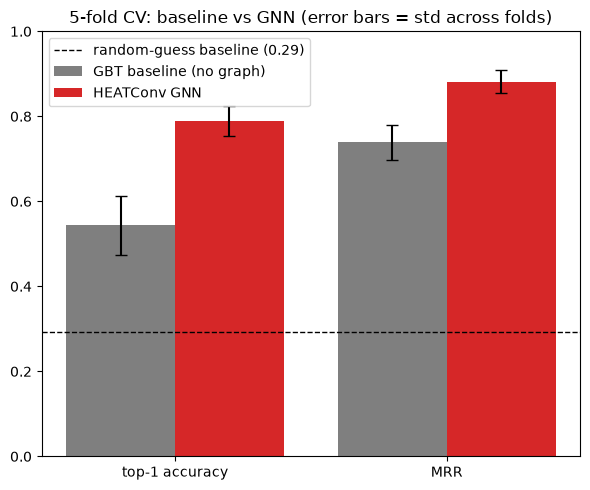

GBT baseline:  top1=0.544+/-0.070   mrr=0.739+/-0.041
HEATConv GNN:  top1=0.789+/-0.036   mrr=0.881+/-0.026


In [29]:
# --- viz: GBT baseline vs HEATConv GNN, mean +/- std across the 5 folds -----
metrics = ["top-1 accuracy", "MRR"]
gbt_means = [np.mean(gbt_accs), np.mean(gbt_mrrs)]
gbt_stds = [np.std(gbt_accs), np.std(gbt_mrrs)]
gnn_means = [np.mean(gnn_accs), np.mean(gnn_mrrs)]
gnn_stds = [np.std(gnn_accs), np.std(gnn_mrrs)]

x = np.arange(len(metrics))
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(x - 0.2, gbt_means, width=0.4, yerr=gbt_stds, capsize=4, color="tab:gray", label="GBT baseline (no graph)")
ax.bar(x + 0.2, gnn_means, width=0.4, yerr=gnn_stds, capsize=4, color="tab:red", label="HEATConv GNN")
ax.axhline(base_rate, color="black", linestyle="--", linewidth=1, label=f"random-guess baseline ({base_rate:.2f})")
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_title("5-fold CV: baseline vs GNN (error bars = std across folds)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"GBT baseline:  top1={gbt_means[0]:.3f}+/-{gbt_stds[0]:.3f}   mrr={gbt_means[1]:.3f}+/-{gbt_stds[1]:.3f}")
print(f"HEATConv GNN:  top1={gnn_means[0]:.3f}+/-{gnn_stds[0]:.3f}   mrr={gnn_means[1]:.3f}+/-{gnn_stds[1]:.3f}")


## 4. Starting the bucket taxonomy (Section 7b)

Item 7 of the plan has two parts: (a) the exclusion list above, and (b)
collapsing the long-tail `action` verbs down to a handful of buckets,
because hundreds of distinct action keys is not something a relation-aware
conv layer (RGCN/HGT/HeteroConv) can usefully learn a separate embedding
for when most of them appear only a handful of times. The `relation_type`
half of that problem is already solved: `_edge_relation_key` now collapses
every `relationship` edge to one shared `"relationship"` key regardless of
its ~270 `relation_type` values, rather than keeping them as separate vocab
entries.

**What are "categories" here?** Every edge key falls into exactly one of
two categories, decided purely by whether it's the collapsed `relationship`
key or not:

- **`action`** — the edge's raw `type` string (`was_at`, `owns`, `kills`,
  ...). Describes something that *happened* (an event, a state, a piece of
  evidence).
- **`relationship`** — the single flat key every `relationship` edge
  collapses to, regardless of its underlying `relation_type` (`classmate`,
  `spouse_of`, ...). Describes a *pre-existing social fact*, independent of
  the crime.

Every single edge has one or the other — there's no third case — because
the category is just "is this edge's collapsed key literally the string
`relationship`", which is true for every `relationship` edge and false for
everything else by construction (`_edge_relation_key` guarantees this). The
cell below counts every edge in the **cleaned** corpus (`cases_v4` — the
dataset future work should actually bin against) and checks that split adds
up to the total, then lists every distinct key with its category and
frequency as the starting catalog for actually assigning buckets to the
`action` long tail (not done here — that's the next step; `relationship`
itself needs no further bucketing, it already collapsed to one key).


In [30]:
# --- full edge-key catalog of the cleaned corpus, ready for binning --------
edge_key_counter = Counter()
edge_key_category = {}
for c in cleaned_cases:
    for e in c["edges"]:
        key = _edge_relation_key(e)
        edge_key_counter[key] += 1
        edge_key_category[key] = "relationship" if key == "relationship" else "action"

action_keys = sorted((k for k in edge_key_counter if edge_key_category[k] == "action"),
                      key=lambda k: -edge_key_counter[k])
relationship_keys = sorted((k for k in edge_key_counter if edge_key_category[k] == "relationship"),
                            key=lambda k: -edge_key_counter[k])

action_total = sum(edge_key_counter[k] for k in action_keys)
relationship_total = sum(edge_key_counter[k] for k in relationship_keys)
total_edges_cleaned = sum(len(c["edges"]) for c in cleaned_cases)
assert action_total + relationship_total == total_edges_cleaned  # every edge has exactly one category

print(f"{len(edge_key_counter)} distinct edge keys in cases_v4 "
      f"({len(action_keys)} action + {len(relationship_keys)} relationship)")
print(f"{action_total} action edges + {relationship_total} relationship edges "
      f"= {action_total + relationship_total} total edges -- every edge is categorized, confirmed")

print(f"\n=== action ({len(action_keys)} keys) ===")
for k in action_keys:
    print(f"  {k:28s} {edge_key_counter[k]:5d}")

print(f"\n=== relationship ({len(relationship_keys)} keys) ===")
for k in relationship_keys:
    print(f"  {k:28s} {edge_key_counter[k]:5d}")


583 distinct edge keys in cases_v4 (582 action + 1 relationship)
7372 action edges + 1343 relationship edges = 8715 total edges -- every edge is categorized, confirmed

=== action (582 keys) ===
  was_at                        2990
  regarding                     1294
  owns                           676
  has_motive_against             599
  located_in                     464
  confronts                      116
  assaults                        61
  frames                          28
  blackmails                      27
  discovers                       21
  accuses                         20
  threatens                       19
  hides                           16
  attempts_to_kill                15
  deceives                        14
  discovers_body_of               14
  gives                           14
  calls                           12
  coerces                         11
  injures                          9
  conceals_death_of                9
  vandalizes                